# Project #3: Visualize Transportation Simulations
**Team:**   150-4
**Date:** 2026-03-31  
**Client:** Federal Highway Administration (FHWA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
sns.set_style('whitegrid')
sns.set_palette('deep')

In [2]:
ngsim_data = pd.read_csv('NGSIM.csv')

In [3]:
nhts_data = pd.read_csv('NHTS.csv') 

census_region
South        5349
Midwest      3707
West         3371
Northeast    2257
Name: count, dtype: int64


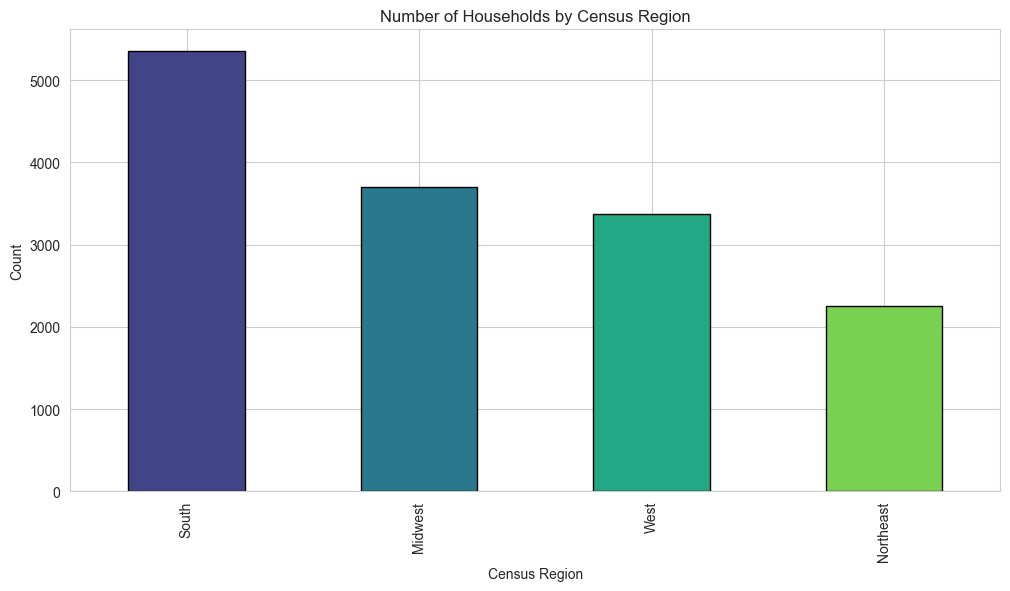

In [4]:
# Simple bar chart: count of vehicles by fuel type
# First we need to count the values, then plot
census_region = nhts_data['census_region'].value_counts().dropna()
print(census_region)

## Step 1: count the number of vehicles by fuel type
# hint: use .value_counts()
plt.figure(figsize = (12,6))

census_region.plot(kind = 'bar', color = sns.color_palette('viridis', len(census_region)), edgecolor = 'black')

## Step 2: create the bar plot
plt.title('Number of Households by Census Region')
plt.xlabel('Census Region')
plt.ylabel('Count')

## Step 3: add labels and customization


## Step 4: show the plot
plt.show()

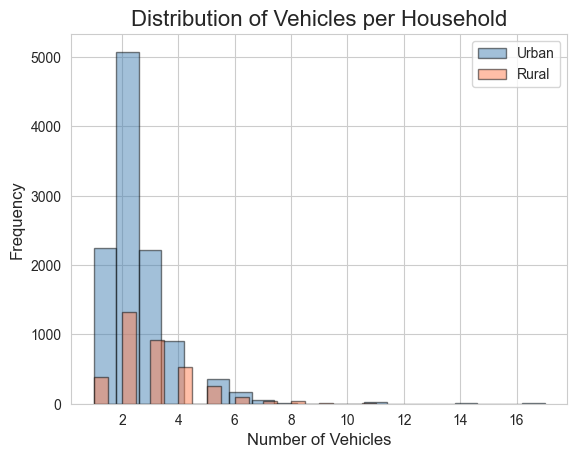

In [5]:

vehicles_urban = nhts_data[nhts_data['household_location'] == 'Urban']['vehicles_per_household']
plt.hist(vehicles_urban, bins = 20, edgecolor = 'black', alpha = 0.5, color='steelblue', label = 'Urban')
## Step 3: filter and plot Rural vehicle ages on the same figure
vehicles_rural = nhts_data[nhts_data['household_location'] == 'Rural']['vehicles_per_household']
plt.hist(vehicles_rural, bins = 20, edgecolor = 'black', alpha = 0.5, color='coral', label = 'Rural')

## Step 4: add labels, title, and legend
plt.title('Distribution of Vehicles per Household', fontsize=16)
plt.xlabel('Number of Vehicles', fontsize = 12)
plt.ylabel('Frequency', fontsize =12)
plt.legend()
plt.show()

<Figure size 1400x600 with 0 Axes>

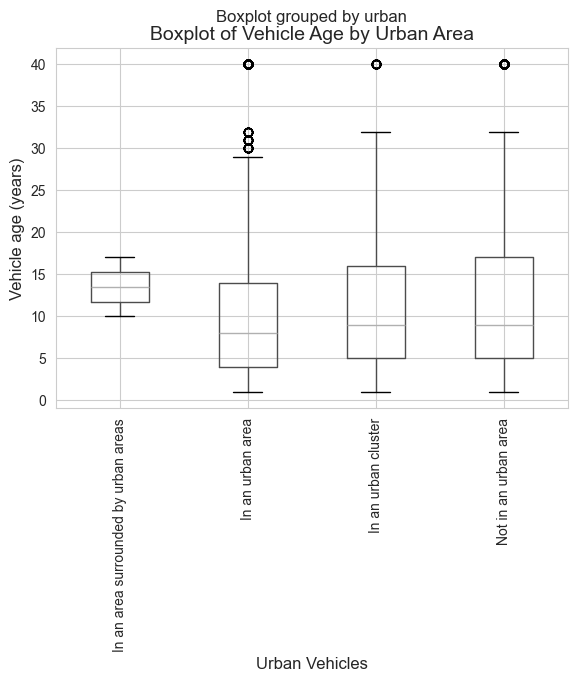

In [6]:
plt.figure(figsize = (14,6))


## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'urban')

## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read
plt.xticks(rotation = 90)

### the next two lines create your axis labels
plt.xlabel('Urban Vehicles', fontsize = 12)
plt.ylabel('Vehicle age (years)', fontsize = 12)
### this line gives your plot a title
plt.title('Boxplot of Vehicle Age by Urban Area', fontsize = 14)

## Step 4: tell python to show the plot

plt.show()

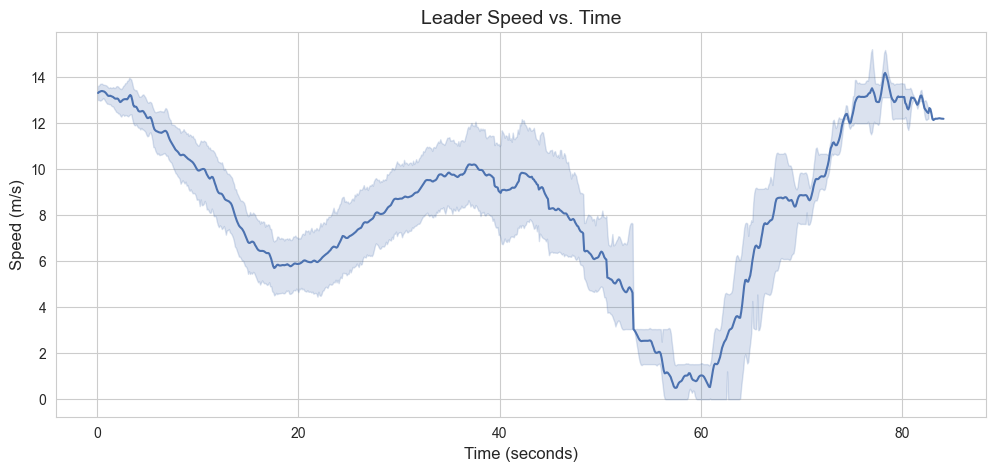

In [29]:
# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize=(12,5))

# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['leader_speed(m/s)'])

# Step 3: add customizations
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Speed (m/s)', fontsize = 12)
plt.title('Leader Speed vs. Time', fontsize = 14)

plt.show()

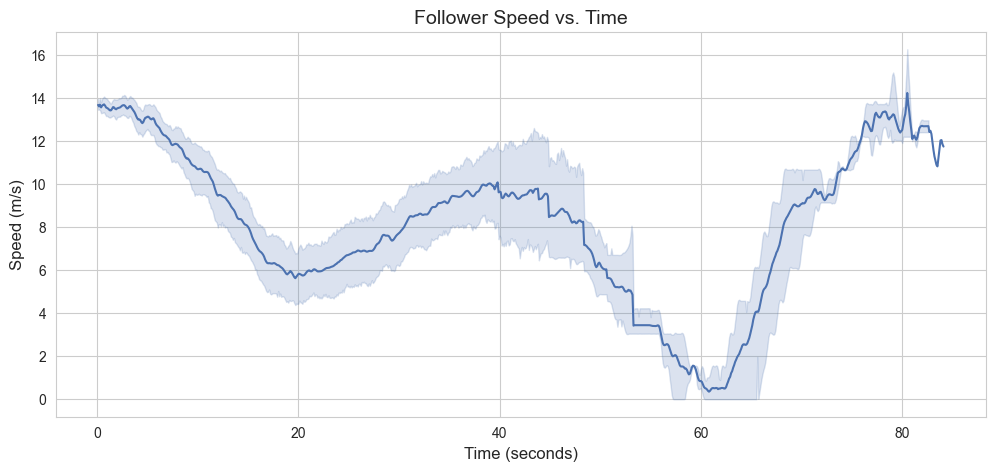

In [32]:
### Plotting Acceleration vs Time

# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize=(12,5))

# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_speed(m/s)'])

# Step 3: add customizations
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Speed (m/s)', fontsize = 12)
plt.title('Follower Speed vs. Time', fontsize = 14)

plt.show()

In [7]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v / v0)**delta - (s_star / s)**2)
    
    return acceleration

In [8]:
# Test the IDM function with sample values
# A follower traveling at 20 m/s, with a gap of 25 m, approaching the leader at 2 m/s

# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Test case
test_v = 20        # follower speed
test_s = 25        # gap distance
test_delta_v = 2   # follower is faster than leader by 2 m/s

# Call the function and print the result
test_acc = idm_acceleration(test_v, test_s, test_delta_v, v0, s0, T, a, b, delta)
print(f"IDM Acceleration: {test_acc:.4f} m/s2")

IDM Acceleration: -2.9348 m/s2


In [9]:
# Load the NGSIM data to get the leader vehicle trajectory

ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair

trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)
# Extract the leader's position and speed over time

time_data = data_subset['Time'].values

leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 #every 0.1 seconds, I will calculate the acceleration value

In [10]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0] 

In [11]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1) # just a condition for gap not to be negative
    delta_v = sim_speed[i] - leader_speed[i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0) # this updates my speed for next iteration based on physics equation of motion
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt
    print(i)

print("Simulation complete!")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

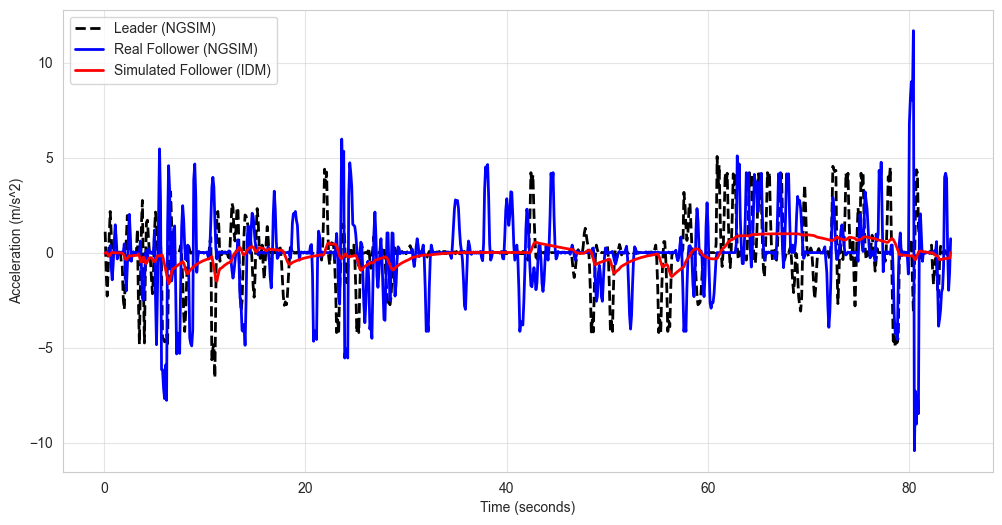

In [12]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower

plt.figure(figsize = (12,6))
plt.plot(time_data, data_subset['leader_acc(m/s^2)'], 'k--', linewidth = 2, label = 'Leader (NGSIM)') # plots leader position vs. time
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, 'b-', linewidth = 2, label = "Real Follower (NGSIM)")# this plots the actual follower position in my NGSIM data
plt.plot(time_data, sim_acc, 'r-', linewidth = 2, label = 'Simulated Follower (IDM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True, alpha = 0.5)
plt.show()